# Recurrent GNNs

In [5]:
from src.dataloading.gnndataloader import GNNDataLoader
from src.utils import get_data_env

modelname   = 'temporal_gcn__'
gg          = 'commuter_t1000_selfmean_rowwise'
name        = modelname + f"{gg}"

disease_name    = 'influenza'
model           = 'tgcn'
nuts_level      = 'nuts3'
min_date        ='2006-05-15'
max_date        = '2020-06-01'
split_trainval  = '2018-06-01'
split_valtest   = '2019-06-01'
split_berlin    = False


horizon_size    = 1
horizon_leadtime= 3
sequence_length = 1
lags            = 1


# training hparams
n_epochs        = 100
lr              = 0.0005
min_delta       = 0.0001
loss            = 'mse'

global_hparams = {
    "lr"                : lr,
    "n_epochs"          : n_epochs,
    "scheduler"         : 'plateau',
    "scheduler_kwargs"  :   {'mode': 'min', 'factor': 0.5, 'patience': 7},
    'min_delta'         : min_delta,
    'loss'              : loss,
    'patience'          : 20,
    }

epidata_loader_basis = GNNDataLoader(disease_name, get_data_env(), nuts_level=nuts_level, min_date=min_date,max_date=max_date, include_population=False, horizon_size = horizon_size, horizon_leadtime = horizon_leadtime, sequence_length=sequence_length, split_berlin=split_berlin)
epidata_loader_basis.add_time_features()
epidata_loader_basis.log_transform_target()
epidata_loader_basis.set_splits(split_trainval, split_valtest)
epidata_loader_basis.normalize()
epidata_loader_basis.add_lagged_features(lags = lags)
epidata_loader_basis.finalize()

Dataloader temporal windowing: extending data collection from 2006-05-15 to 2006-04-17 (+4 weeks)
berlin districts removed


EpiDataLoader(disease=influenza, nuts_level=nuts3, min_date=2006-04-17, max_date=2020-06-01, horizon_size=1, horizon_leadtime=3, sequence_length=1)

In [3]:
# Fix the imports at the top of your files
from typing import Optional, Dict, List, Literal, Any, Union, cast

from src.models.core._basemodel import BaseModel, GNNDataLoader, traincolor, valcolor, testcolor
import matplotlib.pyplot as plt
import torch
import torch.nn.functional as F
from torch_geometric.data import Data
import torch.nn as nn
from torch_geometric.nn import GCNConv, GATConv, ChebConv, GINConv
from torch_geometric_temporal.nn.recurrent import DCRNN, TGCN, A3TGCN
import pandas as pd
import numpy as np
from typing import Optional, Tuple, cast
from src.metrics.losses import spike_weighted_mse, mse, spike_timing_weighted_mse, temporal_smoothness_loss, spike_detection_loss, spatial_consistency_loss
import seaborn as sns
from src.models.weights_manager import ModelWeightsManager

from src.dataloading.dataobjects import GraphDataLoader
import copy
import torch.optim as optim
from torch.optim.optimizer import Optimizer
# from torch.optim import Optimizer

from torch.optim.lr_scheduler import _LRScheduler
from abc import ABC, abstractmethod
from matplotlib.figure import Figure 
from matplotlib.axes import Axes

from tqdm import tqdm



def _check_dataloader_validity(dataloader: 'GNNDataLoader') -> Tuple[GraphDataLoader, GraphDataLoader, GraphDataLoader]:

    if dataloader.dataloader_train is None or dataloader.dataloader_val is None or dataloader.dataloader_test is None:
        raise ValueError(f'dataloader invalid. No dataloaders found for train/val/test')

    train = cast(GraphDataLoader, dataloader.dataloader_train)
    val   = cast(GraphDataLoader, dataloader.dataloader_val)
    test  = cast(GraphDataLoader, dataloader.dataloader_test)

    return train, val, test


class DeepModel(BaseModel, ABC):
    """
    Parent (model) class for all deep models. 

    Parameters:
    ----------
    Inherits parameters from parent

    Updated attributes:
    ------------------
    Only those associated with metadata from GNNDataLoader.

    Workflow:
    --------
    set_model_hparams

    set_global_hparams
        the same function for all models.

    train

    predict

    show_forecasts
    """    
    def __init__(self, dataloader: 'GNNDataLoader', name: Optional[str] = None):
        super().__init__(dataloader, name)    

        self.horizon_size = dataloader.horizon_size

        self.gnn_dataloader: 'GNNDataLoader'                 = dataloader
        self.train_loader, self.val_loader, self.test_loader = _check_dataloader_validity(dataloader)
        self.device                                          = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
        self.model: Optional[torch.nn.Module]                = None 
        self.optimizer: Optional[optim.optimizer.Optimizer]  = None
        self.scheduler: Optional[_LRScheduler]               = None

        # Add weights manager
        self.weights_manager = ModelWeightsManager()

        self.config_info['task'] = self.gnn_dataloader.task_config

        self.config_info['child'] = 'deepmodel'

        # State tracking
        self._state = {
            'model_initialized': False,
            'global_hparams_set': False,
            'trained': False
        }

        # monitoring training
        self.train_losses   = []
        self.val_losses     = []
        self.epoch_patience = []
        self.learning_rates = [] 

    @abstractmethod
    def set_model_hparams(self) -> Any:
        pass

    def _check_state(self, required_states: List[str]) -> None:
        """Validate that required setup steps have been completed."""
        missing = [s for s in required_states if not self._state.get(s, False)]
        if missing:
            raise ValueError(
                f"Missing required setup steps: {', '.join(missing)}. "
                f"Call the corresponding methods first."
            )

    def _get_optimizer(self, optimizer_name: str, lr: float, optimizer_kwargs: Dict[str, Any]) -> Optimizer:
        """Factory method to create and return optimizer"""
        if self.model is None:
            raise ValueError('Please initiate a model')

        # pylance struggles with torch typing?
        optimizer_map = {
            'adam':    optim.Adam,     # type: ignore
            'adamw':   optim.AdamW,    # type: ignore
            'sgd':     optim.SGD,      # type: ignore
            'rmsprop': optim.RMSprop,  # type: ignore
            'adagrad': optim.Adagrad,  # type: ignore
        }
        
        if optimizer_name.lower() not in optimizer_map:
            raise ValueError(f"Optimizer '{optimizer_name}' not supported. Choose from: {list(optimizer_map.keys())}")
        
        optimizer_class = optimizer_map[optimizer_name.lower()]

        return optimizer_class(self.model.parameters(), lr=lr, **optimizer_kwargs)

    def _get_scheduler(self, scheduler_name: str, optimizer: Optimizer, scheduler_kwargs: Dict[str, Any]) -> _LRScheduler:
        """Factory method to create and return scheduler"""
        if self.model is None:
            raise ValueError('Please initiate a model')
        scheduler_map = {
            'step':        torch.optim.lr_scheduler.StepLR,
            'exponential': torch.optim.lr_scheduler.ExponentialLR,
            'cosine':      torch.optim.lr_scheduler.CosineAnnealingLR,
            'plateau':     torch.optim.lr_scheduler.ReduceLROnPlateau,
            'cyclic':      torch.optim.lr_scheduler.CyclicLR,
            'onecycle':    torch.optim.lr_scheduler.OneCycleLR,
            'multistep':   torch.optim.lr_scheduler.MultiStepLR,
            'lambda':      torch.optim.lr_scheduler.LambdaLR,
        }
        
        if scheduler_name.lower() not in scheduler_map:
            raise ValueError(f"Scheduler '{scheduler_name}' not supported. Choose from: {list(scheduler_map.keys())}")
        
        scheduler_class = scheduler_map[scheduler_name.lower()]
        return scheduler_class(optimizer, **scheduler_kwargs)

    def set_global_hparams(self, 
                            lr: float                                  = 0.001,
                            n_epochs: int                              = 5,
                            patience: int                              = 15,
                            min_delta: float                           = 1e-4,                            
                            optimizer: str                             = 'adam',
                            optimizer_kwargs: Optional[Dict[str, Any]] = None,
                            scheduler: Optional[str]                   = 'step',
                            scheduler_kwargs: Optional[Dict[str, Any]] = None,
                            loss: str = 'mse',
                            loss_kwargs: Optional[Dict[str, Any]] = None

                            ):  
        """
        Prepares model for training using global hyperparameters. 
        Set model hyperparameters first!

        Parameters:
        ----------
        lr: float = 0.001,
            learning rate. Typically used between 10E-6 - 10E-3
        n_epochs: int = 5
            number of epochs to train the model
        patience: int = 15
            the number of patience loops
        min_delta: float = 1e-4
            minimal change in loss for model to be updated (and exit patience loop)            
        optimizer: str = 'adam'
            optimizer. Mostly use adam.
        optimizer_kwargs: Optional[Dict[str, Any]] = None
            additional arguments needed to initiate the optimizer
        scheduler: Optional[str] = 'step'
            scheduler.
        scheduler_kwargs: Optional[Dict[str, Any]] = None
            additional arguments needed to initiate the scheduler.
        loss: Literal['spike_weighted_mse', 'mse',
                        'mae', 'huber','smooth_L1',
                        'spatial_consistency',
                        'spike_detection',
                        'temporal_smoothness'] = 'mse'
            loss function

        """
        self._check_state(['model_initialized'])

        global_params_config = {
            'lr': lr,
            'n_epochs': n_epochs,
            'patience': patience,
            'min_delta': min_delta  ,                       
            'optimizer': optimizer,
            'optimizer_kwargs': optimizer_kwargs,
            'scheduler': scheduler,
            'scheduler_kwargs': scheduler_kwargs,
            'loss': loss,
            'loss_kwargs' : loss_kwargs
        }
        
        self.global_hparams_set = True
        # Set training parameters
        self.n_epochs  = n_epochs
        self.patience  = patience
        self.min_delta = min_delta
        self.loss = LossHandler(loss, loss_kwargs=loss_kwargs)      

        if optimizer_kwargs is None:
            optimizer_kwargs = {}
        
        if scheduler_kwargs is None:
            # Default scheduler kwargs for common schedulers
            default_scheduler_kwargs = {
                'step':        {'step_size': 15, 'gamma': 0.8},
                'exponential': {'gamma': 0.95},
                'plateau':     {'mode': 'min', 'factor': 0.5, 'patience': 10, 'verbose': True}
            }
            scheduler_kwargs = default_scheduler_kwargs.get(scheduler, {}) if scheduler else {}

        # Create optimizer
        self.optimizer = self._get_optimizer(optimizer, lr, optimizer_kwargs)
        
        # Create scheduler (optional)
        if scheduler:
            self.scheduler = self._get_scheduler(scheduler, self.optimizer, scheduler_kwargs)

        else:
            self.scheduler = None


        self.config_info['global_hparams'] = global_params_config
        self._state['global_hparams_set'] = True
        return self

    def train(self,
            verbose: Literal[0,1,2] = 1,
            dataloader_snapshot: bool = True,
            show_loss: bool = True):
        """
        trains model following early stopping checkpoint approach.
        Handles both per-batch and epoch-frequency losses transparently.
        
        For epoch-frequency losses (e.g., CorrelationLoss):
        - Accumulates predictions across all batches
        - Computes loss at epoch end
        - Single backward pass per epoch
        
        For per-batch losses (e.g., MSE):
        - Standard per-batch backward as usual
        """
        if self.model is None:
            raise ValueError('Please initiate a model')
        
        if self.optimizer is None:
            raise ValueError('no valid optimizer found')

        if self.scheduler is None:
            raise ValueError('no valid scheduler found')
        
        self._check_state(['model_initialized', 'global_hparams_set'])

        if dataloader_snapshot:
            print(f'Dataloader Snapshot: {self.train_loader[0]}')

        # verbose
        if verbose == 1:
            verbose_loops = list(np.arange(1, self.n_epochs + 1, step=10))
        elif verbose == 2:
            verbose_loops = list(np.arange(1, self.n_epochs + 1))
        else:
            verbose_loops = []

        self.model.train()
        best_val_loss    = float('inf')
        patience_counter = 0
        best_model_state = None

        list_val_loss   = []
        list_train_loss = []
        list_patience   = []

        L_train = len(list(self.train_loader))
        L_val   = len(list(self.val_loader))
        
        if verbose == 0:
            epoch_iter = tqdm(range(self.n_epochs), desc="Training epochs")
        else:
            epoch_iter = range(self.n_epochs)

        for epoch in epoch_iter:

            # ======================== TRAINING PHASE ========================
            total_loss = 0
            
            # Per-batch loss: standard training loop
            for snapshot in self.train_loader:
                snapshot = snapshot.to(self.device)
                self.optimizer.zero_grad()
                y_hat = self.model(snapshot.x, snapshot.edge_index, snapshot.edge_weight)

                loss = self.loss(y_hat, snapshot.y)
                loss.backward()
                self.optimizer.step()
                total_loss += loss.item()
            
            train_mse = total_loss / L_train
            
            list_train_loss.append(train_mse)

            # ======================== VALIDATION PHASE ========================
            self.model.eval()
            val_loss = 0

            with torch.no_grad():

                # Per-batch validation
                for snapshot in self.val_loader:
                    snapshot = snapshot.to(self.device)
                    y_hat = self.model(snapshot.x, snapshot.edge_index, snapshot.edge_weight)
                    loss = self.loss(y_hat, snapshot.y)
                    val_loss += loss.item()
                
                val_mse = val_loss / L_val
            
            list_val_loss.append(val_mse)
            current_lr = self.optimizer.param_groups[0]['lr']
            self.learning_rates.append(current_lr)
            
            self.model.train()
            
            # Check if validation loss improved
            val_improved = val_mse < (best_val_loss - self.min_delta)

            if val_improved:
                best_val_loss    = val_mse
                patience_counter = 0
                best_model_state = self.model.state_dict().copy()
                if epoch in verbose_loops:
                    print(f"Epoch {epoch} train loss: {train_mse:.4f}, val loss: {val_mse:.4f} ✓ (new best)")
                list_patience.append(False)

            else:
                patience_counter += 1
                if epoch in verbose_loops:
                    print(f"Epoch {epoch} train loss: {train_mse:.4f}, val loss: {val_mse:.4f} (patience: {patience_counter}/{self.patience})")
                list_patience.append(True)
                
                if patience_counter >= self.patience:
                    print(f"Early stopping: Validation loss hasn't improved for {self.patience} epochs")
                    if best_model_state is not None:
                        self.model.load_state_dict(best_model_state)
                        print(f"Restored model from best validation loss: {best_val_loss:.4f}")
                    break
            
            # Step scheduler
            if isinstance(self.scheduler, torch.optim.lr_scheduler.ReduceLROnPlateau):
                self.scheduler.step(val_mse)
            else:
                self.scheduler.step()
            
            self.train_losses   = list_train_loss
            self.val_losses     = list_val_loss
            self.epoch_patience = list_patience

        self._state['trained'] = True
        if show_loss:
            self.plot_losses()

    def plot_losses(self) -> Tuple[Figure, Axes]:
        """
        returns plot of train and val losses per epoch, after training model.
        """

        if self.model is None:
            raise ValueError('Please initiate a model')

        epochs                = np.arange(len(self.train_losses))
        patience_epochs       = epochs[np.array(self.epoch_patience)]
        patience_train_losses = np.array(self.train_losses)[np.array(self.epoch_patience)]
        patience_val_losses   = np.array(self.val_losses)[np.array(self.epoch_patience)]
        patience_learningrates= np.array(self.learning_rates)[np.array(self.epoch_patience)]

        fig, axes = plt.subplots(1, 3, figsize=(24, 4))
        axes = axes.flatten()

        sns.lineplot(self.train_losses, color = traincolor, label = 'train loss', ax = axes[0])
        sns.lineplot(self.val_losses,   color = valcolor,   label = 'val loss',   ax = axes[1])
        sns.lineplot(self.learning_rates, color='green', label='learning rate', ax=axes[2])
        
        axes[0].scatter(patience_epochs, patience_train_losses, color='red', marker = 'x', label='Patience Epochs')
        axes[1].scatter(patience_epochs, patience_val_losses,   color='red', marker = 'x', label='Patience Epochs')   
        axes[2].scatter(patience_epochs, patience_learningrates,   color='red', marker = 'x', label='Patience Epochs')           

        for ax in axes:
            ax.grid()
            ax.set_ylabel('loss')
            ax.set_xlabel('epoch')
            ax.legend()

        axes[0].set_title('Training loss')      
        axes[1].set_title('Validation loss')    
        axes[2].set_title('Learning Rate Schedule')
        
        # Learning rate
        axes[2].set_ylabel('Learning Rate')
        axes[2].set_yscale('log')

        return (fig, axes)

    def run_snapshot(self, index: int = 0, debug: bool = False):
        """
        Run a single snapshot through the model and print output for validation/debugging.
        """
        if self.model is None:
            raise ValueError('Please initiate a model')

        self.model.eval()  # Set model to eval mode

        # Get snapshot from dataloader
        snapshot = self.train_loader[index]
        snapshot = snapshot.to(self.device)

        with torch.no_grad():
            # Forward pass
            y_hat = self.model(snapshot.x, snapshot.edge_index, snapshot.edge_weight, debug=debug)

        # Ground truth
        y_true = snapshot.y.to(self.device)

        # Compute error
        loss = F.mse_loss(y_hat, y_true).item()

        # Print summary
        if debug:
            print(f"\n🧪 Snapshot {index} validation summary:")
            print(f"➡️  Predicted shape: {y_hat.shape}")
            print(f"➡️  Ground truth shape: {y_true.shape}")

        print(f"✅ Snapshot ran successfully")

        return y_hat, y_true

    def save_weights(self,
                     filename: Optional[str] = None,
                     save_optimizer: bool = True,
                     save_scheduler: bool = True,
                     metadata: Optional[Dict] = None) -> str:
        """
        Save model weights only (not configuration).
        
        For saving configuration, use the parent's save_model() method.
        
        Parameters:
        ----------
        filename : Optional[str]
            Custom filename (without extension)
        save_optimizer : bool
            Save optimizer state for training resumption
        save_scheduler : bool
            Save scheduler state for training resumption
        metadata : Optional[Dict]
            Additional metadata to store
            
        Returns:
        -------
        str : Path to saved weights file
        
        Example:
        -------
        >>> # Save config once (in BaseModel)
        >>> model.save_model()  # Saves config to YAML
        >>> 
        >>> # Save weights multiple times during training
        >>> model.save_weights(filename='epoch_50')
        >>> model.save_weights(filename='epoch_100')
        >>> model.save_weights(filename='best_model', save_optimizer=False)
        """
        if self.model is None:
            raise ValueError('No model to save')
        
        weights_path = self.weights_manager.save_weights(
            model=self,
            filename=filename,
            save_optimizer=save_optimizer,
            save_scheduler=save_scheduler,
            metadata=metadata
        )
        
        return weights_path
    
    def _load_weights(self,
                     model_number: int) -> 'DeepModel':
        """
        Load model weights.
        Model architecture should already be initialized via set_model_hparams().
        
        Parameters:
        ----------
        weights_path : str
            Path to the weights file
        load_optimizer : bool
            Load optimizer state
        load_scheduler : bool
            Load scheduler state
        strict : bool
            Strictly enforce key matching
            
        Returns:
        -------
        self : For method chaining
        """
        metadata = self.weights_manager.load_weights(
            model=self,
            model_number=model_number
        )
        
        # Update config_info with loaded metadata
        if metadata.get('config_id'):
            self.config_info['id'] = metadata['config_id']
        
        return self
    
    def load_config(self, model_name: str):

        cfg      = self.config_manager.load_entry(entry_name = model_name)
        entry_id = cfg['id']

        if self.__class__.__name__.lower() != cfg['model']:
            raise ValueError(f'The config loaded is one of a {cfg["model"]} which does not work for {self.name}, given it is a {self.__class__.__name__}')

        self.set_model_hparams(**cfg['model_hparams'])
        self.set_global_hparams(**cfg['global_hparams'])
        self._load_weights(model_number= entry_id)
        print(f"✓ Model loaded")

    def forecast(self, dataset: Literal['train','val','test'] = 'test'):
        """
        Forecasts and evaluates on dataset specified.
        Handles both per-batch and epoch-level losses.
        """
        self._check_state(['model_initialized', 'global_hparams_set', 'trained'])
        if self.model is None:
            raise ValueError('Please initiate a model')

        self.model.eval()
        
        predictions = []
        labels = []

        eval_df = self.gnn_dataloader.data['final'][self.gnn_dataloader.data['final'][dataset]]

        if dataset == 'train':
            dataloader = self.train_loader
        elif dataset == 'val':
            dataloader = self.val_loader
        elif dataset == 'test':
            dataloader = self.test_loader
        else:
            raise ValueError(f'dataset must be either "train", "val" or "test"')


        # ======================== FORECASTING LOOP ========================
        with torch.no_grad():
            for snapshot in tqdm(dataloader, desc=f"Forecasting {dataset}"):
                snapshot = snapshot.to(self.device)
                y_hat = self.model(snapshot.x, snapshot.edge_index, snapshot.edge_weight)
                _ = self.loss(y_hat, snapshot.y)

                labels.append(snapshot.y)
                predictions.append(y_hat)

        # Compute loss
        # For per-batch losses, recompute from scratch (no accumulation in eval)
        loss = 0
        with torch.no_grad():
            for snapshot in dataloader:
                snapshot = snapshot.to(self.device)
                y_hat = self.model(snapshot.x, snapshot.edge_index, snapshot.edge_weight)
                loss += self.loss(y_hat, snapshot.y).item()
        loss = loss / len(dataloader)
    
        print(f"{dataset.capitalize()} loss: {loss:.4f}")
        setattr(self, f'{dataset}_loss', loss)

        # ======================== FORMAT PREDICTIONS ========================
        tensor_list_cpu = [t.detach().cpu() for t in predictions]
        stacked = torch.stack(tensor_list_cpu)   
        num_timepoints, n_nodes, horizon = stacked.shape
        reshaped = stacked.view(num_timepoints * n_nodes, horizon).numpy()  

        timepoints = np.repeat(np.arange(num_timepoints), n_nodes)
        nodes = np.tile(np.arange(n_nodes), num_timepoints)
        index = pd.MultiIndex.from_arrays([timepoints, nodes], names=['timestamp_idx', 'node'])

        columns = [f"pred_h{h}" for h in range(horizon)]
        df_pred = pd.DataFrame(reshaped, index=index, columns=columns).reset_index(drop=False)

        # ======================== FORMAT TARGETS ========================
        tensor_list_cpu = [t.detach().cpu() for t in labels]
        stacked = torch.stack(tensor_list_cpu)   
        num_timepoints, n_nodes, horizon = stacked.shape
        reshaped = stacked.view(num_timepoints * n_nodes, horizon).numpy()  

        timepoints = np.repeat(np.arange(num_timepoints), n_nodes)
        nodes = np.tile(np.arange(n_nodes), num_timepoints)
        index = pd.MultiIndex.from_arrays([timepoints, nodes], names=['timestamp_idx', 'node'])

        columns = self.gnn_dataloader.target_horizons
        df_target = pd.DataFrame(reshaped, index=index, columns=columns).reset_index(drop=False)
        
        merged = pd.merge(df_pred, df_target, on=['timestamp_idx','node'])
        merged['timestamp_idx'] = merged['timestamp_idx'] + (self.gnn_dataloader.sequence_length - 1)
        timestamp_map = eval_df[['timestamp']].drop_duplicates().reset_index(drop=True).reset_index(drop=False).rename(columns={'index': 'timestamp_idx'})
        merged['timestamp'] = merged['timestamp_idx'].map(dict(zip(timestamp_map['timestamp_idx'], timestamp_map['timestamp'])))
        
        formatted_eval = pd.merge(merged[['timestamp', 'node'] + [f'pred_h{hh}' for hh in range(horizon)]], eval_df, on=['timestamp','node'], how='right')

        columns_context = [self.gnn_dataloader.temporal_column, self.gnn_dataloader.id_column] + self.gnn_dataloader.feature_columns + self.gnn_dataloader.split_columns + [self.gnn_dataloader.target_horizons[0]]

        horizon_prediction_dict = {}

        for hh in range(horizon):
            horizon_predictions = formatted_eval[columns_context + [f'pred_h{hh}']]
            horizon_predictions = horizon_predictions.rename(columns={
                f'pred_h{hh}': 'pred',
                f'{self.gnn_dataloader.target_horizons[0]}': f'{self.gnn_dataloader.target_column}'
            })
            horizon_predictions['pred'] = horizon_predictions['pred'].shift(-hh)

            horizon_prediction_dict['transformed'] = {f'horizon_{hh}': horizon_predictions}
            horizon_prediction_dict['nontransformed'] = {f'horizon_{hh}': self._denorm_predictions(horizon_predictions)}

        self.evaluation_datasets[dataset] = horizon_prediction_dict
        return self

    def __str__(self):
        max_len = max(len(state) for state in self._state.keys())
        max_len = max(max_len, max(len(hparam) for hparam in self.config_info['model_hparams'].keys()))
        max_len = max(max_len, max(len(hparam) for hparam in self.config_info['global_hparams'].keys()))
        max_len = max(max_len, len('model name'), len('model class'))
        
        status_lines = [f'    {state:<{max_len}} : ✓' for state in self._state.keys()]
        model_hparam_lines = [f'    {hparam:<{max_len}} : {value}' for hparam, value in self.config_info['model_hparams'].items()]
        global_hparam_lines = [f'    {hparam:<{max_len}} : {value}' for hparam, value in self.config_info['global_hparams'].items()]
        
        lines = [
            '<DeepModel(',
            f"    {'model name':<{max_len}} : {self.name}",
            f"    {'model class':<{max_len}} : {self.__class__.__name__}",
            '',
            '    ----------- STATUS --------------',
            *status_lines,
            '    ----------- FORECASTS -----------',
            f"    {'forecasted':<{max_len}} : {list(self.evaluation_datasets.keys())}",
            '    ----------- MODEL HPARAMS -------',
            *model_hparam_lines,
            '    ----------- GLOBAL HPARAMS ------',
            *global_hparam_lines,
            ')>'
        ]
        
        return '\n'.join(lines)

/home/de-schrijvers/.conda/envs/gnenv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [4]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.nn import GCNConv, GATConv, ChebConv, GINConv
from torch_geometric_temporal.nn.recurrent import DCRNN, TGCN, A3TGCN
import pandas as pd
import numpy as np
from typing import Optional, Tuple
from src.dataloading.gnndataloader import GNNDataLoader
from src.utils.constants import paired_colors

class RecurrentTemporalGCN(nn.Module):
    """
    Recurrent Temporal Graph Convolutional Network.
    Processes one time step at a time and keeps hidden state between steps.
    Suitable for streaming or recurrent training with hidden state memory.
    """
    def __init__(self, node_features: int, hidden_size: int = 64, num_layers: int = 2,
                 dropout: float = 0.2, temporal_layers: int = 1, prediction_horizon: int = 1):
        super().__init__()
        
        self.node_features = node_features
        self.hidden_size = hidden_size
        self.num_layers = num_layers
        self.temporal_layers = temporal_layers
        self.prediction_horizon = prediction_horizon

        # Spatial GCN layers
        self.spatial_convs = nn.ModuleList()
        self.spatial_convs.append(GCNConv(node_features, hidden_size))
        for _ in range(num_layers - 1):
            self.spatial_convs.append(GCNConv(hidden_size, hidden_size))

        # Temporal recurrence via LSTMCell or LSTM
        self.temporal_rnn = nn.LSTM(
            input_size=hidden_size,
            hidden_size=hidden_size,
            num_layers=temporal_layers,
            dropout=dropout if temporal_layers > 1 else 0,
        )

        # Output head
        self.output_proj = nn.Sequential(
            nn.Linear(hidden_size, hidden_size // 2),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_size // 2, prediction_horizon)
        )

        self.output_scale = nn.Parameter(torch.tensor(3.0))
        self.dropout = nn.Dropout(dropout)

    def forward(self,
                x_t: torch.Tensor,
                edge_index: torch.Tensor,
                edge_weight: Optional[torch.Tensor] = None,
                hidden_state: Optional[Tuple[torch.Tensor, torch.Tensor]] = None,
                debug: bool = False
                ) -> Tuple[torch.Tensor, Tuple[torch.Tensor, torch.Tensor]]:
        """
        Forward pass for one time step.
        
        x_t: [num_nodes, node_features]
        edge_index: [2, num_edges]
        edge_weight: [num_edges] or None
        hidden_state: Tuple (h, c), each [num_layers, num_nodes, hidden_size]
        
        Returns:
            output: [num_nodes, prediction_horizon]
            hidden_state: Tuple (h, c)
        """

        # --- 1. Spatial GCN processing ---
        if debug:
            print("input shape:", x_t.shape)

        h = x_t.squeeze(-1)

        for conv in self.spatial_convs:
            h = conv(h, edge_index, edge_weight)
            h = F.relu(h)
            h = self.dropout(h)

        # --- 2. Add batch dim for LSTM: [1, num_nodes, hidden_size] ---
        h = h.unsqueeze(0)

        if debug:
            print('h shape:', h.shape)

        # --- 3. Temporal LSTM ---
        if hidden_state is None:
            lstm_out, new_hidden = self.temporal_rnn(h)
        else:
            lstm_out, new_hidden = self.temporal_rnn(h, hidden_state)

        # --- 4. Output projection using last output (we only have 1 time step) ---
        last_hidden = lstm_out.squeeze(0)  # [num_nodes, hidden_size]
        output = self.output_proj(last_hidden)  # [num_nodes, prediction_horizon]
        output = output * self.output_scale

        if debug:
            print('output shape:', output.shape)

        return output, new_hidden
from torch_geometric.nn import GATv2Conv
class RecurrentGATv2(nn.Module):
    """
    Recurrent GATv2-based spatiotemporal model.
    Processes a single time step at a time and keeps hidden state between steps.
    """
    def __init__(self,
                 node_features: int,
                 hidden_size: int = 64,
                 num_layers: int = 2,
                 dropout: float = 0.2,
                 temporal_layers: int = 1,
                 prediction_horizon: int = 1,
                 heads: int = 2):
        super().__init__()

        self.node_features = node_features
        self.hidden_size = hidden_size
        self.num_layers = num_layers
        self.temporal_layers = temporal_layers
        self.prediction_horizon = prediction_horizon

        # === Spatial GATv2 layers ===
        self.spatial_convs = nn.ModuleList()
        self.spatial_convs.append(GATv2Conv(node_features, hidden_size, heads=heads, dropout=dropout))

        for _ in range(num_layers - 1):
            self.spatial_convs.append(
                GATv2Conv(hidden_size * heads, hidden_size, heads=heads, dropout=dropout)
            )

        self.total_gat_out_dim = hidden_size * heads

        # === Temporal LSTM ===
        self.temporal_rnn = nn.LSTM(
            input_size=self.total_gat_out_dim,
            hidden_size=hidden_size,
            num_layers=temporal_layers,
            dropout=dropout if temporal_layers > 1 else 0,
        )

        # === Output layer ===
        self.output_proj = nn.Sequential(
            nn.Linear(hidden_size, hidden_size // 2),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_size // 2, prediction_horizon)
        )

        self.output_scale = nn.Parameter(torch.tensor(3.0))
        self.dropout = nn.Dropout(dropout)

    def forward(self,
                x_t: torch.Tensor,
                edge_index: torch.Tensor,
                edge_weight: Optional[torch.Tensor] = None,
                hidden_state: Optional[Tuple[torch.Tensor, torch.Tensor]] = None,
                debug: bool = False
                ) -> Tuple[torch.Tensor, Tuple[torch.Tensor, torch.Tensor]]:
        """
        Forward pass for one time step.

        x_t: [num_nodes, node_features]
        edge_index: [2, num_edges]
        hidden_state: Tuple (h, c), each [num_layers, num_nodes, hidden_size]
        """
        # --- 1. Spatial GCN processing ---
        if debug:
            print("input shape:", x_t.shape)

        h = x_t.squeeze(-1)

        for gat in self.spatial_convs:
            h = gat(h, edge_index)
            h = F.elu(h)
            h = self.dropout(h)

        # Add time dim: [1, num_nodes, features]
        h = h.unsqueeze(0)

        if hidden_state is None:
            lstm_out, new_hidden = self.temporal_rnn(h)
        else:
            lstm_out, new_hidden = self.temporal_rnn(h, hidden_state)

        last_hidden = lstm_out.squeeze(0)  # [num_nodes, hidden_size]
        output = self.output_proj(last_hidden)
        output = output * self.output_scale

        return output, new_hidden

class RecurrentTGCNModel(DeepModel):
    """
    Purely spatial GCN model that does not use temporal axis.
    Useful to validate the use of graph-structure
    """
    def __init__(self, 
                 dataloader: GNNDataLoader, 
                 name: Optional[str] = None):
        super().__init__(dataloader, name=name)
        if not self.name:
            self.name = 'TGCN'

        self.model_color = paired_colors[3]
        self.dataloader = dataloader
        self.config_info['model'] = 'tgcnmodel'

    def set_model_hparams(self, hidden_size: int = 64, num_layers: int = 2,
                         temporal_layers: int = 2, dropout: float = 0.2):
        self.model_hparams_set = True
        self.model = RecurrentGATv2(
            node_features=len(self.dataloader.feature_columns),
            hidden_size=hidden_size,
            num_layers=num_layers,
            temporal_layers=temporal_layers,
            dropout=dropout,
            prediction_horizon= self.dataloader.horizon_size
        ).to(self.device)
        
        model_hparams_config = {'hidden_size': hidden_size,
                                'num_layers' : num_layers,
                                'temporal_layers':temporal_layers,
                                'dropout':dropout}

        self.config_info['model_hparams'] = model_hparams_config
        self._state['model_initialized'] = True


        return self
    
    def train(self,
                verbose: Literal[0,1,2] = 1,
                dataloader_snapshot: bool = True,
                show_loss: bool = True):
            """
            trains model following early stopping checkpoint approach.
            Handles both per-batch and epoch-frequency losses transparently.
            
            For epoch-frequency losses (e.g., CorrelationLoss):
            - Accumulates predictions across all batches
            - Computes loss at epoch end
            - Single backward pass per epoch
            
            For per-batch losses (e.g., MSE):
            - Standard per-batch backward as usual
            """
            if self.model is None:
                raise ValueError('Please initiate a model')
            
            if self.optimizer is None:
                raise ValueError('no valid optimizer found')

            if self.scheduler is None:
                raise ValueError('no valid scheduler found')
            
            self._check_state(['model_initialized', 'global_hparams_set'])

            if dataloader_snapshot:
                print(f'Dataloader Snapshot: {self.train_loader[0]}')

            # verbose
            if verbose == 1:
                verbose_loops = list(np.arange(1, self.n_epochs + 1, step=10))
            elif verbose == 2:
                verbose_loops = list(np.arange(1, self.n_epochs + 1))
            else:
                verbose_loops = []

            self.model.train()
            best_val_loss    = float('inf')
            patience_counter = 0
            best_model_state = None

            list_val_loss   = []
            list_train_loss = []
            list_patience   = []

            L_train = len(list(self.train_loader))
            L_val   = len(list(self.val_loader))
            
            if verbose == 0:
                epoch_iter = tqdm(range(self.n_epochs), desc="Training epochs")
            else:
                epoch_iter = range(self.n_epochs)

            for epoch in epoch_iter:

                # ======================== TRAINING PHASE ========================
                total_loss      = 0
                hidden_state    = None                                                                              # ONLY DIFFERENCE
                
                # Per-batch loss: standard training loop
                for snapshot in self.train_loader:
                    snapshot    = snapshot.to(self.device)
                    self.optimizer.zero_grad()
                    y_hat, hidden_state = self.model(snapshot.x, snapshot.edge_index, snapshot.edge_weight,hidden_state)
                    hidden_state = tuple(h.detach() for h in hidden_state)
                    if hidden_state is not None:
                        hidden_state = tuple(h.to(self.device) for h in hidden_state)
                    loss = self.loss(y_hat, snapshot.y)
                    loss.backward()
                    self.optimizer.step()
                    total_loss += loss.item()
                
                train_mse = total_loss / L_train
                
                list_train_loss.append(train_mse)

                # ======================== VALIDATION PHASE ========================
                self.model.eval()
                val_loss = 0
                hidden_state    = None    

                with torch.no_grad():

                    # Per-batch validation
                    for snapshot in self.val_loader:
                        snapshot = snapshot.to(self.device)
                        y_hat, hidden_state = self.model(snapshot.x, snapshot.edge_index, snapshot.edge_weight, hidden_state)
                        hidden_state = tuple(h.detach() for h in hidden_state)
                        if hidden_state is not None:
                            hidden_state = tuple(h.to(self.device) for h in hidden_state)
                        loss = self.loss(y_hat, snapshot.y)
                        val_loss += loss.item()
                    
                    val_mse = val_loss / L_val
                
                list_val_loss.append(val_mse)
                current_lr = self.optimizer.param_groups[0]['lr']
                self.learning_rates.append(current_lr)
                
                self.model.train()
                
                # Check if validation loss improved
                val_improved = val_mse < (best_val_loss - self.min_delta)

                if val_improved:
                    best_val_loss    = val_mse
                    patience_counter = 0
                    best_model_state = self.model.state_dict().copy()
                    if epoch in verbose_loops:
                        print(f"Epoch {epoch} train loss: {train_mse:.4f}, val loss: {val_mse:.4f} ✓ (new best)")
                    list_patience.append(False)

                else:
                    patience_counter += 1
                    if epoch in verbose_loops:
                        print(f"Epoch {epoch} train loss: {train_mse:.4f}, val loss: {val_mse:.4f} (patience: {patience_counter}/{self.patience})")
                    list_patience.append(True)
                    
                    if patience_counter >= self.patience:
                        print(f"Early stopping: Validation loss hasn't improved for {self.patience} epochs")
                        if best_model_state is not None:
                            self.model.load_state_dict(best_model_state)
                            print(f"Restored model from best validation loss: {best_val_loss:.4f}")
                        break
                
                # Step scheduler
                if isinstance(self.scheduler, torch.optim.lr_scheduler.ReduceLROnPlateau):
                    self.scheduler.step(val_mse)
                else:
                    self.scheduler.step()
                
                self.train_losses   = list_train_loss
                self.val_losses     = list_val_loss
                self.epoch_patience = list_patience

            self._state['trained'] = True
            if show_loss:
                self.plot_losses()


    def forecast(self, dataset: Literal['train','val','test'] = 'test'):
        """
        Forecasts and evaluates on dataset specified.
        Handles both per-batch and epoch-level losses.
        """
        self._check_state(['model_initialized', 'global_hparams_set', 'trained'])
        if self.model is None:
            raise ValueError('Please initiate a model')

        self.model.eval()
        
        predictions = []
        labels = []

        eval_df = self.gnn_dataloader.data['final'][self.gnn_dataloader.data['final'][dataset]]

        if dataset == 'train':
            dataloader = self.train_loader
        elif dataset == 'val':
            dataloader = self.val_loader
        elif dataset == 'test':
            dataloader = self.test_loader
        else:
            raise ValueError(f'dataset must be either "train", "val" or "test"')


        # ======================== FORECASTING LOOP ========================

        loss = 0
        hidden_state = None
        with torch.no_grad():
            for snapshot in dataloader:
                snapshot = snapshot.to(self.device)
                y_hat, hidden_state = self.model(snapshot.x, snapshot.edge_index, snapshot.edge_weight, hidden_state)
                hidden_state = tuple(h.detach() for h in hidden_state)
                if hidden_state is not None:
                    hidden_state = tuple(h.to(self.device) for h in hidden_state)
                loss += self.loss(y_hat, snapshot.y).item()

                labels.append(snapshot.y)
                predictions.append(y_hat)

        loss = loss / len(dataloader)

        print(f"{dataset.capitalize()} loss: {loss:.4f}")
        setattr(self, f'{dataset}_loss', loss)


        # ======================== FORMAT PREDICTIONS ========================
        tensor_list_cpu = [t.detach().cpu() for t in predictions]
        stacked = torch.stack(tensor_list_cpu)   
        num_timepoints, n_nodes, horizon = stacked.shape
        reshaped = stacked.view(num_timepoints * n_nodes, horizon).numpy()  

        timepoints = np.repeat(np.arange(num_timepoints), n_nodes)
        nodes = np.tile(np.arange(n_nodes), num_timepoints)
        index = pd.MultiIndex.from_arrays([timepoints, nodes], names=['timestamp_idx', 'node'])

        columns = [f"pred_h{h}" for h in range(horizon)]
        df_pred = pd.DataFrame(reshaped, index=index, columns=columns).reset_index(drop=False)

        # ======================== FORMAT TARGETS ========================
        tensor_list_cpu = [t.detach().cpu() for t in labels]
        stacked = torch.stack(tensor_list_cpu)   
        num_timepoints, n_nodes, horizon = stacked.shape
        reshaped = stacked.view(num_timepoints * n_nodes, horizon).numpy()  

        timepoints = np.repeat(np.arange(num_timepoints), n_nodes)
        nodes = np.tile(np.arange(n_nodes), num_timepoints)
        index = pd.MultiIndex.from_arrays([timepoints, nodes], names=['timestamp_idx', 'node'])

        columns = self.gnn_dataloader.target_horizons
        df_target = pd.DataFrame(reshaped, index=index, columns=columns).reset_index(drop=False)
        
        merged = pd.merge(df_pred, df_target, on=['timestamp_idx','node'])
        merged['timestamp_idx'] = merged['timestamp_idx'] + (self.gnn_dataloader.sequence_length - 1)
        timestamp_map = eval_df[['timestamp']].drop_duplicates().reset_index(drop=True).reset_index(drop=False).rename(columns={'index': 'timestamp_idx'})
        merged['timestamp'] = merged['timestamp_idx'].map(dict(zip(timestamp_map['timestamp_idx'], timestamp_map['timestamp'])))
        
        formatted_eval = pd.merge(merged[['timestamp', 'node'] + [f'pred_h{hh}' for hh in range(horizon)]], eval_df, on=['timestamp','node'], how='right')

        columns_context = [self.gnn_dataloader.temporal_column, self.gnn_dataloader.id_column] + self.gnn_dataloader.feature_columns + self.gnn_dataloader.split_columns + [self.gnn_dataloader.target_horizons[0]]

        horizon_prediction_dict = {}

        for hh in range(horizon):
            horizon_predictions = formatted_eval[columns_context + [f'pred_h{hh}']]
            horizon_predictions = horizon_predictions.rename(columns={
                f'pred_h{hh}': 'pred',
                f'{self.gnn_dataloader.target_horizons[0]}': f'{self.gnn_dataloader.target_column}'
            })
            horizon_predictions['pred'] = horizon_predictions['pred'].shift(-hh)

            horizon_prediction_dict['transformed'] = {f'horizon_{hh}': horizon_predictions}
            horizon_prediction_dict['nontransformed'] = {f'horizon_{hh}': self._denorm_predictions(horizon_predictions)}

        self.evaluation_datasets[dataset] = horizon_prediction_dict
        return self


Dataloader temporal windowing: extending data collection from 2006-05-15 to 2006-04-17 (+4 weeks)
berlin districts removed
Dataloader Snapshot: GraphDataLoaderEntry(x=(400, 3, 1), y=(400, 1), edge_index=(2, 400), edge_weight=(400,))
Epoch 1 train loss: 0.7284, val loss: 1.2096 ✓ (new best)
Epoch 2 train loss: 0.6706, val loss: 1.0723 ✓ (new best)
Epoch 3 train loss: 0.6449, val loss: 0.9708 ✓ (new best)
Epoch 4 train loss: 0.6262, val loss: 0.9014 ✓ (new best)
Epoch 5 train loss: 0.6188, val loss: 0.8325 ✓ (new best)
Epoch 6 train loss: 0.6029, val loss: 0.7880 ✓ (new best)
Epoch 7 train loss: 0.5990, val loss: 0.7405 ✓ (new best)
Epoch 8 train loss: 0.5935, val loss: 0.7076 ✓ (new best)
Epoch 9 train loss: 0.5854, val loss: 0.6921 ✓ (new best)
Epoch 10 train loss: 0.5812, val loss: 0.6715 ✓ (new best)
Epoch 11 train loss: 0.5754, val loss: 0.6460 ✓ (new best)
Epoch 12 train loss: 0.5778, val loss: 0.6351 ✓ (new best)
Epoch 13 train loss: 0.5688, val loss: 0.6242 ✓ (new best)
Epoch 14 

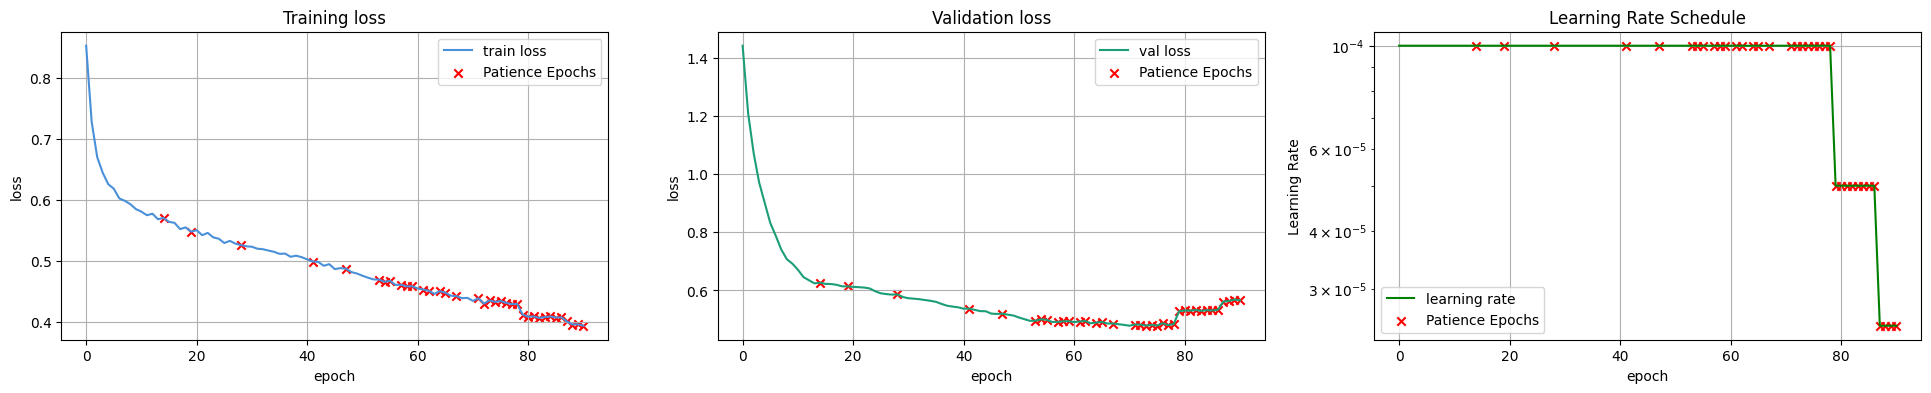

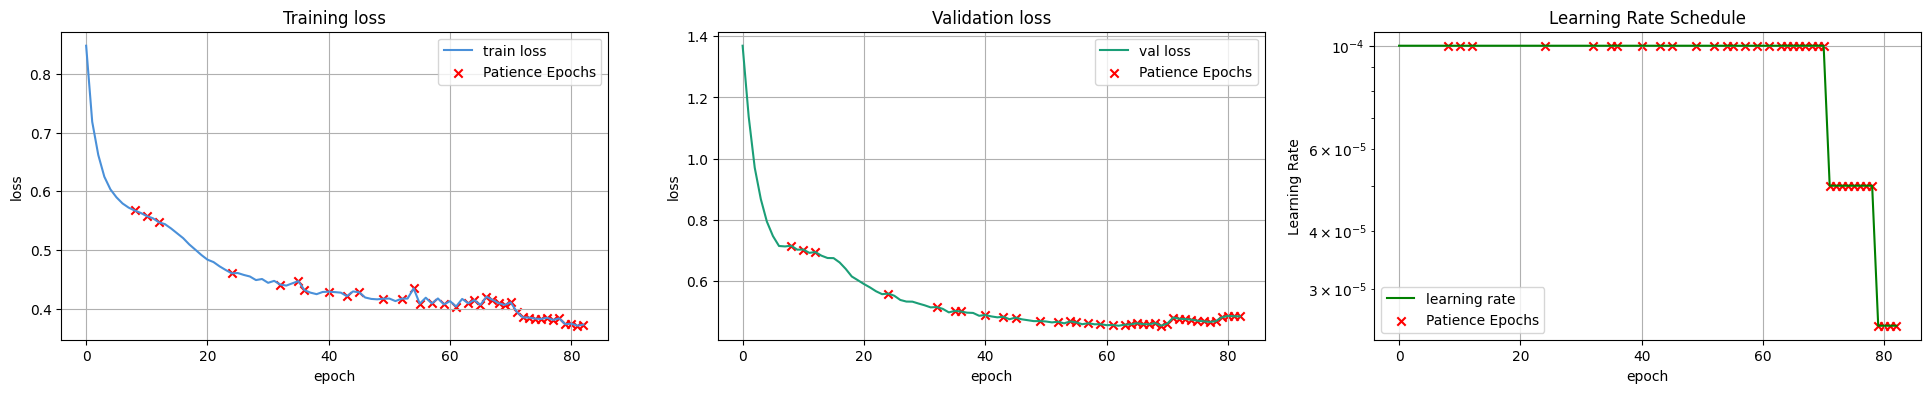

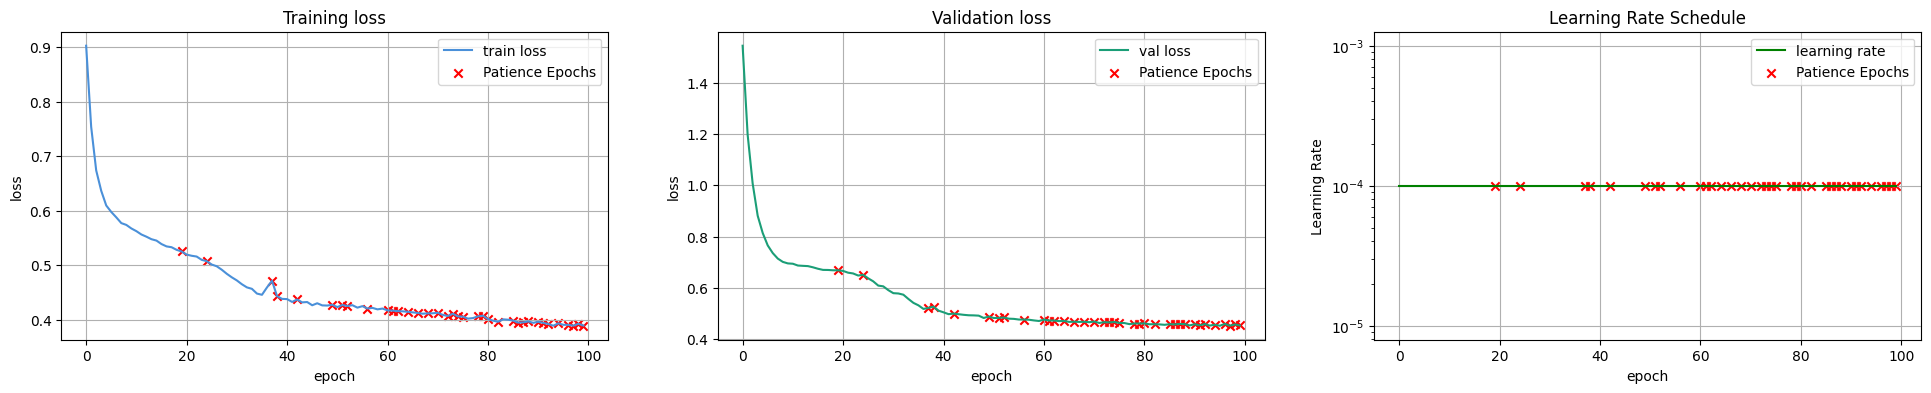

In [7]:
modelname   = 'recurrent_gnn'



disease_name    = 'influenza'

nuts_level      = 'nuts3'
min_date        ='2006-05-15'
max_date        = '2020-06-01'
split_trainval  = '2018-06-01'
split_valtest   = '2019-06-01'
split_berlin    = False


horizon_size    = 1
horizon_leadtime= 3
sequence_length = 12
lags            = 1


# training hparams
n_epochs        = 100
lr              = 0.0001
min_delta       = 0.0001
loss            = 'mse'

global_hparams = {
    "lr"                : lr,
    "n_epochs"          : n_epochs,
    "scheduler"         : 'plateau',
    "scheduler_kwargs"  :   {'mode': 'min', 'factor': 0.5, 'patience': 7},
    'min_delta'         : min_delta,
    'loss'              : loss,
    'patience'          : 20,
}

graphs = ['identity_selfmax','boolean_neighbors_selfmean','commuter_t1000_selfmean_rowwise']

models={}

for gg in graphs:
    dl = epidata_loader_basis.copy().retrieve_graph(gg).construct_dataloaders()

    name        = modelname + f"{gg}"

    ml = RecurrentTGCNModel(dl, name = name)
    ml.set_model_hparams()
    ml.set_global_hparams(**global_hparams)
    # ml.run_snapshot(0,debug=True)
    ml.train(verbose = 2)
    ml.forecast('test')

    models[name] = ml



In [8]:
from src.metrics.evaluator import Evaluator

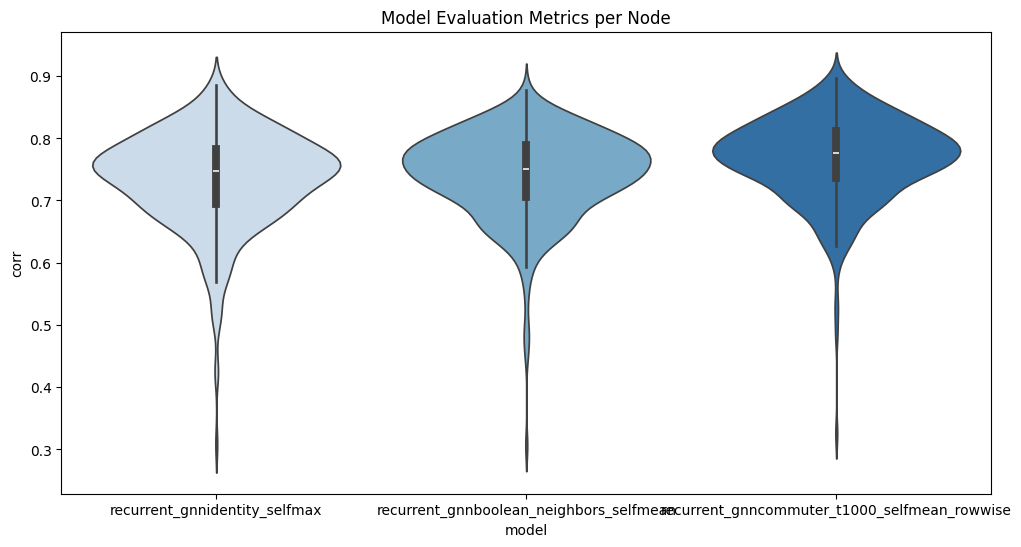

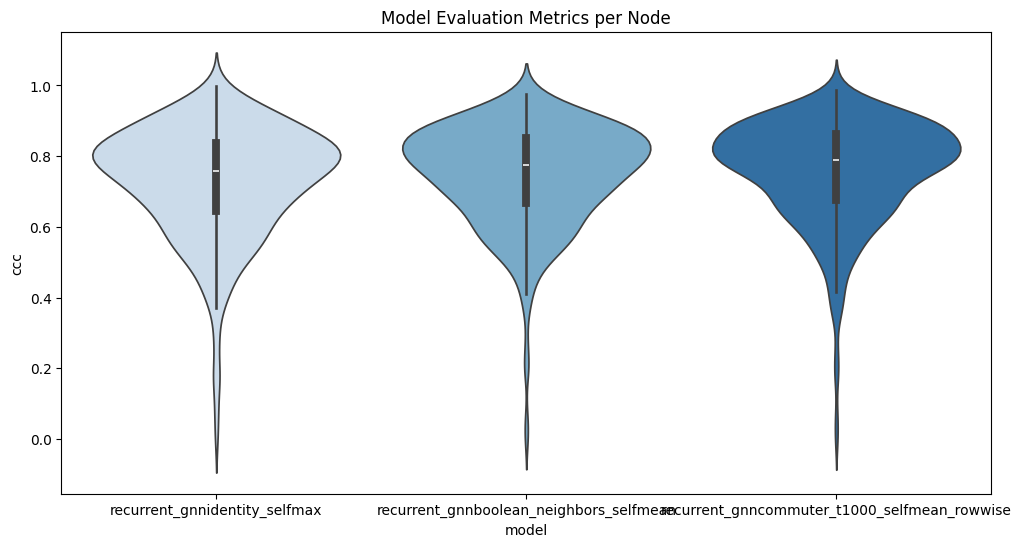

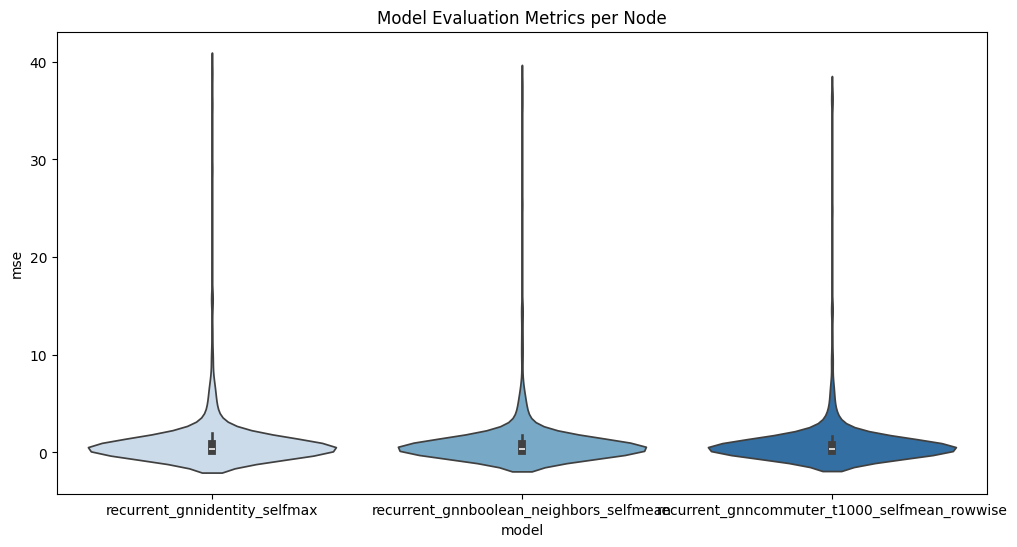

In [10]:
evaluation = Evaluator(list(models.values()))
evaluation.add_evaluation()
evaluation.plot_metric('corr')
evaluation.plot_metric('ccc')
evaluation.plot_metric('mse')

2019-12-23 00:00:00


/home/de-schrijvers/projects/germany_gnn/src/models/core/_basemodel.py:210: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


(<Figure size 1200x900 with 3 Axes>, array([<Axes: >, <Axes: >], dtype=object))

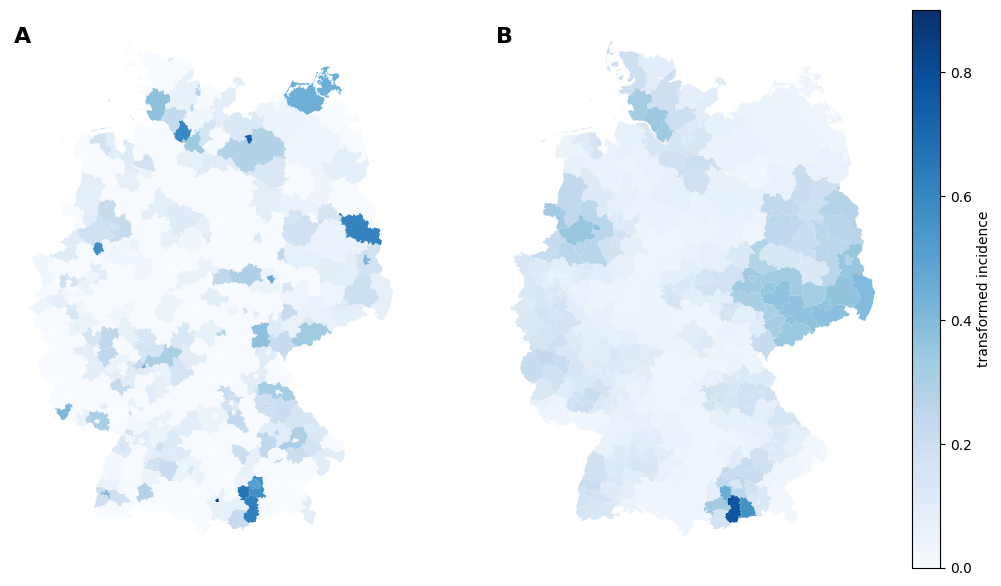

In [12]:
ml.show_forecasts_maps('test',29,'equal')
